#### Heart Disease Prediction Using Logistic Regression

In [19]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
disease_df = pd.read_csv("../data/framingham.csv")

disease_df.drop(columns=['education'], inplace = True, axis = 1)
disease_df.rename(columns ={'male':'Sex_male'}, inplace = True)
disease_df.head(5)


,Sex_male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [10]:
# remove rows with missing values
disease_df.dropna(axis=0,inplace=True)
disease_df.shape

(3751, 15)

In [11]:

print(disease_df.TenYearCHD.value_counts())

TenYearCHD
0    3179
1     572
Name: count, dtype: int64


#### Splitting the Dataset into Test and Train Sets

In [24]:
X = disease_df.drop('TenYearCHD', axis=1)
y = disease_df['TenYearCHD']

X_train, X_test, y_train, y_test = train_test_split( 
        X, y, test_size = 0.3, random_state = 4)
                           

#####  Feature Scaling

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Logistic Regression Model

In [37]:
model = LogisticRegression(max_iter=100, random_state=4)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,4
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


####  Predictions

In [38]:
y_pred = model.predict(X_test_scaled)

### Evaluate the Model

In [40]:
print("Accuracy", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy 0.8525754884547069

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       951
           1       0.70      0.09      0.16       175

    accuracy                           0.85      1126
   macro avg       0.78      0.54      0.54      1126
weighted avg       0.83      0.85      0.80      1126



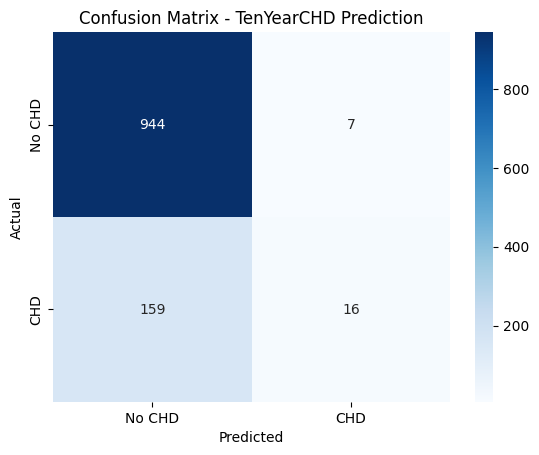

In [41]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No CHD', 'CHD'], 
            yticklabels=['No CHD', 'CHD'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TenYearCHD Prediction")
plt.show()

#### Predict for a New Patient

In [51]:
new_patient = pd.DataFrame({
    'Sex_male': [1],
    'age': [55],
    'currentSmoker': [1],
    'cigsPerDay': [20],
    'BPMeds': [0],
    'prevalentStroke': [0],
    'prevalentHyp': [1],
    'diabetes': [0],
    'totChol': [240],
    'sysBP': [145],
    'diaBP': [85],
    'BMI': [27.0],
    'heartRate': [72],
    'glucose': [90]
})

new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)

print("Prediction:", "Likely CHD" if prediction[0]==1 else "Unlikely CHD")


Prediction: Unlikely CHD
